# TP Méthodes d'Ensemble - Partie 1 : Voting Classifier 

Implémenter vous-même les Voting Classifiers (Hard et Soft).


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from matplotlib.patches import Patch


## 0. Chargement des donnees


In [11]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')
df = df.dropna()
df['target'] = (df['target'] > 0).astype(int)

X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset charge : {len(df)} echantillons")


Dataset charge : 297 echantillons


## 1. Entrainement des modeles de base


In [12]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

model_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
model_tree.fit(X_train, y_train)

model_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)

models = [
    ('Logistic Regression', model_lr, True),
    ('Decision Tree', model_tree, False),
    ('Random Forest', model_rf, False)
]

individual_scores = {}

for name, model, needs_scaling in models:
    X_eval = X_test_scaled if needs_scaling else X_test
    score = accuracy_score(y_test, model.predict(X_eval))
    individual_scores[name] = score
    print(f"   {name:25s}: {score:.4f}")


   Logistic Regression      : 0.8333
   Decision Tree            : 0.7000
   Random Forest            : 0.8167


## 2. Hard Voting (Vote Majoritaire)


In [13]:
def hard_voting_predict(models_list, X_raw, X_scaled):
    """Hard Voting : chaque modele vote pour une classe, la majorite gagne."""
    n_samples = X_raw.shape[0]
    n_models = len(models_list)
    
    all_predictions = np.zeros((n_models, n_samples), dtype=int)
    
    for i, (name, model, needs_scaling) in enumerate(models_list):
        X_eval = X_scaled if needs_scaling else X_raw
        all_predictions[i] = model.predict(X_eval)
    
    final_predictions = np.zeros(n_samples, dtype=int)
    
    for j in range(n_samples):
        votes = all_predictions[:, j]
        vote_counts = np.bincount(votes, minlength=2)
        final_predictions[j] = np.argmax(vote_counts)
    
    return final_predictions

y_pred_hard = hard_voting_predict(models, X_test, X_test_scaled)
acc_hard = accuracy_score(y_test, y_pred_hard)
print(f"Hard Voting : {acc_hard:.4f}")


Hard Voting : 0.8333


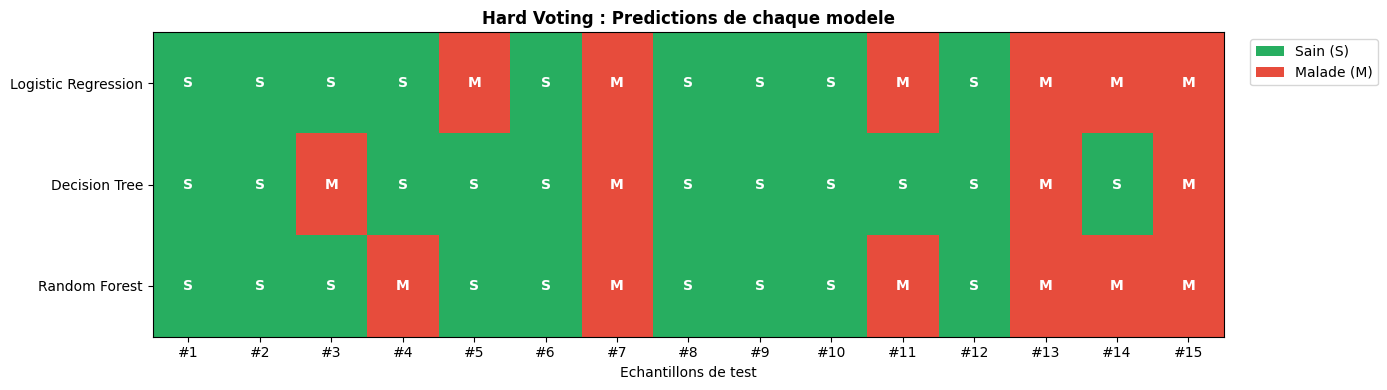

In [14]:
n_examples = 15
predictions_matrix = np.zeros((len(models), n_examples), dtype=int)

for i, (name, model, needs_scaling) in enumerate(models):
    X_eval = X_test_scaled[:n_examples] if needs_scaling else X_test[:n_examples]
    predictions_matrix[i] = model.predict(X_eval)

fig, ax = plt.subplots(figsize=(14, 4))
cmap = plt.cm.colors.ListedColormap(['#27ae60', '#e74c3c'])
ax.imshow(predictions_matrix, cmap=cmap, aspect='auto')

ax.set_yticks(range(len(models)))
ax.set_yticklabels([name for name, _, _ in models])
ax.set_xticks(range(n_examples))
ax.set_xticklabels([f'#{i+1}' for i in range(n_examples)])
ax.set_xlabel('Echantillons de test')
ax.set_title('Hard Voting : Predictions de chaque modele', fontweight='bold')

for i in range(len(models)):
    for j in range(n_examples):
        text = 'M' if predictions_matrix[i, j] == 1 else 'S'
        ax.text(j, i, text, ha='center', va='center', color='white', fontweight='bold')

legend_elements = [Patch(facecolor='#27ae60', label='Sain (S)'),
                   Patch(facecolor='#e74c3c', label='Malade (M)')]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()


## 3. Soft Voting (Moyenne des Probabilites)


In [15]:
def soft_voting_predict(models_list, X_raw, X_scaled):
    """Soft Voting : moyenne des probabilites, classe avec plus haute proba gagne."""
    n_samples = X_raw.shape[0]
    n_models = len(models_list)
    
    all_probas = np.zeros((n_models, n_samples, 2))
    
    for i, (name, model, needs_scaling) in enumerate(models_list):
        X_eval = X_scaled if needs_scaling else X_raw
        if hasattr(model, 'predict_proba'):
            all_probas[i] = model.predict_proba(X_eval)
        else:
            preds = model.predict(X_eval)
            all_probas[i, :, 0] = 1 - preds
            all_probas[i, :, 1] = preds
    
    mean_probas = np.mean(all_probas, axis=0)
    final_predictions = np.argmax(mean_probas, axis=1)
    
    return final_predictions, mean_probas

y_pred_soft, probas_soft = soft_voting_predict(models, X_test, X_test_scaled)
acc_soft = accuracy_score(y_test, y_pred_soft)
print(f"Soft Voting : {acc_soft:.4f}")


Soft Voting : 0.8333


## 4. Comparaison avec sklearn


In [16]:
estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42))
]

sklearn_hard = VotingClassifier(estimators=estimators, voting='hard')
sklearn_hard.fit(X_train_scaled, y_train)
acc_sklearn_hard = sklearn_hard.score(X_test_scaled, y_test)

sklearn_soft = VotingClassifier(estimators=estimators, voting='soft')
sklearn_soft.fit(X_train_scaled, y_train)
acc_sklearn_soft = sklearn_soft.score(X_test_scaled, y_test)

print(f"Mon Hard Voting     : {acc_hard:.4f}")
print(f"Sklearn Hard Voting : {acc_sklearn_hard:.4f}")
print(f"Mon Soft Voting     : {acc_soft:.4f}")
print(f"Sklearn Soft Voting : {acc_sklearn_soft:.4f}")


Mon Hard Voting     : 0.8333
Sklearn Hard Voting : 0.8333
Mon Soft Voting     : 0.8333
Sklearn Soft Voting : 0.8333


## 5. Comparaison finale


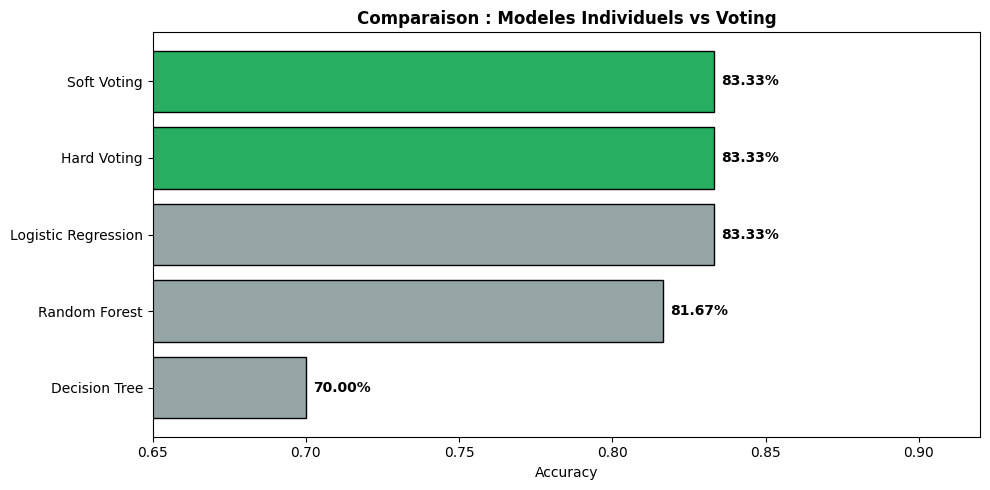

In [17]:
all_scores = individual_scores.copy()
all_scores['Hard Voting'] = acc_hard
all_scores['Soft Voting'] = acc_soft

sorted_scores = dict(sorted(all_scores.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#95a5a6' if 'Voting' not in k else '#27ae60' for k in sorted_scores.keys()]
y_pos = np.arange(len(sorted_scores))

bars = ax.barh(y_pos, list(sorted_scores.values()), color=colors, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(list(sorted_scores.keys()))
ax.set_xlabel('Accuracy')
ax.set_title('Comparaison : Modeles Individuels vs Voting', fontweight='bold')
ax.set_xlim(0.65, 0.92)

for bar, score in zip(bars, sorted_scores.values()):
    ax.annotate(f'{score:.2%}', 
                xy=(score, bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


In [18]:
best_individual = max(individual_scores.values())
print(f"Meilleur individuel : {best_individual:.4f}")
print(f"Hard Voting         : {acc_hard:.4f} ({(acc_hard - best_individual)*100:+.2f}%)")
print(f"Soft Voting         : {acc_soft:.4f} ({(acc_soft - best_individual)*100:+.2f}%)")


Meilleur individuel : 0.8333
Hard Voting         : 0.8333 (+0.00%)
Soft Voting         : 0.8333 (+0.00%)
